<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_12_SVM_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 12 - Support Vector Machine (SVM) Classification Model

## Project
AI-Based Student Performance Prediction System

## Internship
YBI Foundation - Python AI & Data Science Internship

## Objective
The objective of Day 12 is to train and evaluate a Support Vector Machine
(SVM) classification model for predicting student performance categories.

The SVM model will be trained as an untuned baseline model and compared
with the classification models developed during previous days:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

The evaluation will focus especially on Macro F1-score because the project
contains multiple performance categories and each class should be considered
during evaluation.

## Day 12 Learning Goals

By the end of this notebook, the following tasks will be completed:

1. Load the student performance dataset.
2. Recreate the project-defined performance categories.
3. Separate features and target.
4. Prevent target leakage by removing `G3` from model inputs.
5. Split the dataset using a stratified train-test split.
6. Prepare categorical and numerical features.
7. Apply scaling to numerical and ordinal features.
8. Build an SVM classification pipeline.
9. Train the baseline SVM model.
10. Evaluate the model using multiple classification metrics.
11. Analyze the confusion matrix.
12. Compare SVM with the previous four models.
13. Rank all five models using Macro F1-score.
14. Save the model comparison results.

## Why Support Vector Machine?

Support Vector Machine (SVM) is a supervised machine learning algorithm
that can be used for classification problems.

SVM attempts to find a decision boundary that separates different classes
while maximizing the margin between them.

For this project, SVM is useful because:

- The problem is a multiclass classification problem.
- The dataset contains a mixture of numerical and categorical features.
- Feature scaling can be applied before SVM training.
- SVM can model non-linear class boundaries when using an RBF kernel.

The SVM used today is a baseline model. Hyperparameter tuning will be
performed later in the project.

In [1]:
# Install the dataset library
!pip -q install ucimlrepo

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# Display library versions

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

import sklearn
print("Scikit-learn version:", sklearn.__version__)

NumPy version: 2.1.3
Pandas version: 2.2.3
Scikit-learn version: 1.6.1


## 1. Load Dataset

The UCI Student Performance dataset is used for this project.

The dataset contains demographic, social, family, study-related and
academic information about students.

The final grade `G3` is used to create the project-defined performance
category.

In [4]:
# Fetch the UCI Student Performance dataset

student_performance = fetch_ucirepo(id=320)

X_original = student_performance.data.features
y_original = student_performance.data.targets

# Create working dataframe
df = X_original.copy()

# Add final grade
df["G3"] = y_original["G3"]

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (649, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


In [5]:
# Function to create the project-defined performance category

def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"


# Create target column
df["performance_category"] = df["G3"].apply(performance_category)

print("Performance category created successfully.")

display(
    df[["G3", "performance_category"]].head(10)
)

Performance category created successfully.


,G3,performance_category
0,11,Medium
1,11,Medium
2,12,Medium
3,14,Medium
4,13,Medium
5,13,Medium
6,13,Medium
7,13,Medium
8,17,High
9,13,Medium


In [6]:
# Check target distribution

print("Performance category distribution:")

display(
    df["performance_category"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

Performance category distribution:


,count
performance_category,
Low,100
Medium,418
High,131


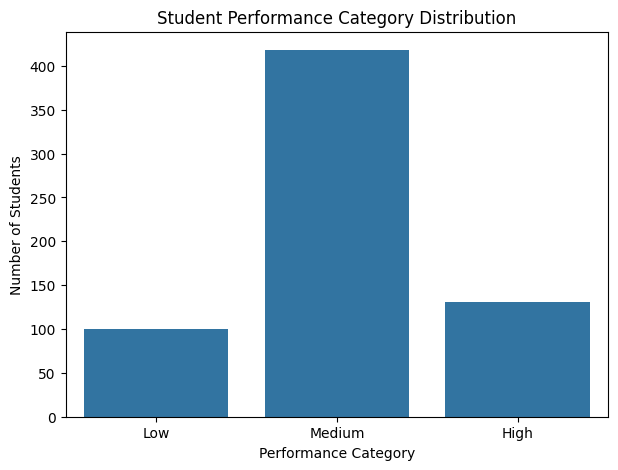

In [7]:
# Visualize target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="performance_category",
    order=["Low", "Medium", "High"]
)

plt.title("Student Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

## 3. Separate Features and Target

The target variable is:

`performance_category`

The column `G3` must not be used as an input feature.

This is important because the performance category is directly created
from `G3`.

If `G3` were included during model training, the model would receive
information that directly determines the target. This would create
target leakage and produce an unreliable evaluation.

Therefore, `G3` is removed before model training.

In [8]:
# Separate target from input data

target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

# Remove G3 to prevent target leakage
X_model = X.drop(columns=["G3"])

print("Original feature count:", X.shape[1])
print("Model feature count:", X_model.shape[1])

print("\nTarget column:", target)
print("G3 present in model features:", "G3" in X_model.columns)

print("\nTarget distribution:")
display(y.value_counts().reindex(["Low", "Medium", "High"]))

Original feature count: 31
Model feature count: 30

Target column: performance_category
G3 present in model features: False

Target distribution:


,count
performance_category,
Low,100
Medium,418
High,131


In [9]:
# Display model input columns

print("Features used for model training:\n")

for i, column in enumerate(X_model.columns, start=1):
    print(f"{i}. {column}")

Features used for model training:

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences


## 4. Define Feature Groups

The features are divided into different groups based on their data type
and meaning.

### Numerical Features
- age
- absences

### Ordinal Features
These contain ordered values:

- Medu
- Fedu
- traveltime
- studytime
- failures
- famrel
- freetime
- goout
- Dalc
- Walc
- health

### Binary Features
- school
- sex
- address
- famsize
- Pstatus
- schoolsup
- famsup
- paid
- activities
- nursery
- higher
- internet
- romantic

### Nominal Features
- Mjob
- Fjob
- reason
- guardian

Categorical variables will be converted using One-Hot Encoding.

Numerical and ordinal features will be standardized because SVM is
sensitive to feature scale.

In [10]:
# Define feature groups

numerical_features = [
    "age",
    "absences"
]

ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

binary_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

nominal_features = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

categorical_features = binary_features + nominal_features

print("Numerical features:", len(numerical_features))
print("Ordinal features:", len(ordinal_features))
print("Binary features:", len(binary_features))
print("Nominal features:", len(nominal_features))
print("Total categorical features:", len(categorical_features))

Numerical features: 2
Ordinal features: 11
Binary features: 13
Nominal features: 4
Total categorical features: 17


In [11]:
# Verify that all feature groups are present

all_grouped_features = (
    numerical_features
    + ordinal_features
    + categorical_features
)

missing_features = [
    feature for feature in all_grouped_features
    if feature not in X_model.columns
]

print("Missing features:", missing_features)

if len(missing_features) == 0:
    print("All feature groups are valid.")
else:
    print("Please check the feature definitions.")

Missing features: []
All feature groups are valid.


## 5. Train-Test Split

The dataset will be divided into:

- 80% training data
- 20% testing data

`stratify=y` is used so that the class distribution remains approximately
consistent between the training and testing datasets.

The same random state used in previous model notebooks is retained:

`random_state = 42`

This makes model comparisons more consistent.

In [12]:
# Create stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
)

print("\nTesting target distribution:")
display(
    y_test.value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
)

Training samples: 519
Testing samples: 130

Training target distribution:


,proportion
performance_category,
Low,0.154143
Medium,0.643545
High,0.202312



Testing target distribution:


,proportion
performance_category,
Low,0.153846
Medium,0.646154
High,0.200000


## 6. Build SVM Preprocessing Pipeline

SVM uses distances and margins to identify class boundaries.

Therefore, numerical and ordinal features should be placed on a comparable
scale.

The preprocessing pipeline will perform:

### Categorical Features
One-Hot Encoding

### Numerical + Ordinal Features
Standard Scaling

The preprocessing will be fitted only on the training data through the
Scikit-learn Pipeline.

This prevents information from the test dataset from influencing
preprocessing.

In [13]:
# Create preprocessing components

categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

numerical_scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            numerical_scaler,
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("SVM preprocessing configuration created successfully.")

SVM preprocessing configuration created successfully.


## 7. Create Baseline SVM Model

A Support Vector Classifier with an RBF kernel will be used.

The model is intentionally kept as a baseline.

No hyperparameter tuning is performed today.

The parameters such as `C` and `gamma` will be investigated during the
future hyperparameter tuning stage.

In [14]:
# Create baseline SVM classifier

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

print("Baseline SVM model created.")
print(svm_model)

Baseline SVM model created.
SVC(probability=True, random_state=42)


In [15]:
# Create complete SVM pipeline

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", svm_model)
])

print("SVM pipeline created successfully.")

SVM pipeline created successfully.


In [16]:
# Train the SVM pipeline

svm_pipeline.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [17]:
# Generate predictions

y_train_pred = svm_pipeline.predict(X_train)
y_test_pred = svm_pipeline.predict(X_test)

print("Training predictions generated:", len(y_train_pred))
print("Testing predictions generated:", len(y_test_pred))

Training predictions generated: 519
Testing predictions generated: 130


## 8. Evaluate SVM Model

The following metrics will be calculated:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

Macro averaging gives equal importance to each performance category.

This is useful because the project is a multiclass classification problem.

In [18]:
# Calculate SVM evaluation metrics

svm_accuracy = accuracy_score(y_test, y_test_pred)

svm_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

svm_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]
})

display(svm_results)

,Metric,Score
0,Accuracy,0.661538
1,Macro Precision,0.469577
2,Macro Recall,0.379365
3,Macro F1,0.346825


In [19]:
# Display formatted metrics

print("SVM Test Performance")
print("-" * 35)

print(f"Accuracy        : {svm_accuracy:.4f}")
print(f"Macro Precision : {svm_precision:.4f}")
print(f"Macro Recall    : {svm_recall:.4f}")
print(f"Macro F1        : {svm_f1:.4f}")

SVM Test Performance
-----------------------------------
Accuracy        : 0.6615
Macro Precision : 0.4696
Macro Recall    : 0.3794
Macro F1        : 0.3468


## 9. Classification Report

The classification report provides class-level precision, recall and F1-score.

This helps identify whether the SVM performs similarly across Low, Medium
and High performance categories.

In [20]:
# Classification report

print("SVM Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

SVM Classification Report
              precision    recall  f1-score   support

         Low       0.75      0.15      0.25        20
      Medium       0.66      0.99      0.79        84
        High       0.00      0.00      0.00        26

    accuracy                           0.66       130
   macro avg       0.47      0.38      0.35       130
weighted avg       0.54      0.66      0.55       130

